# Baselines & Metrics — Implementing the Evaluation Stack
## IIT414W · Unit I · Week 3 · Wednesday March 18, 2026

**Learning goals for this session:**
- Define and implement 4 categories of baselines (random, majority-class, domain heuristic, prior-period)
- Justify metric choice based on class distribution and decision context
- Compare baselines and interpret what the gap reveals about the prediction problem
- Apply the leakage guard checklist to your own features

**Before you start:** You should have completed Lab 1 (EDA + baseline) and Monday's leakage session. Every Lab 1 group converged on grid ≤ 10 as the domain heuristic — today you formalize that with code.

**Session structure:**
| Block | Time | Activity |
|-------|------|----------|
| A | 13:50–14:10 | Corrections + fold-tracing (instructor-led, no notebook) |
| B | 14:10–14:25 | Baseline taxonomy + live demo (type along) |
| C | 14:25–15:30 | **Studio: implement baselines on YOUR data + peer audit** |
| D | 15:30–15:45 | Metric justification discussion |
| E | 15:45–15:55 | Lab 2 release |
| F | 15:55–16:20 | Leakage self-audit + exit ticket |

<div style="border-left: 6px solid #1f77b4; padding: 16px 20px; background: #242525 0%; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">

## 📊 Classification Metrics — A Conceptual Guide

Before writing any code, let's build solid intuition for the metrics we will use throughout the course. Every metric answers a **different question** about your model's behavior, and choosing the wrong one can hide critical failures.

---

### The Confusion Matrix — Foundation of All Metrics

Every binary classification metric is derived from four counts:

|  | **Predicted Positive** | **Predicted Negative** |
|--|----------------------|----------------------|
| **Actually Positive** | True Positive (TP) | False Negative (FN) |
| **Actually Negative** | False Positive (FP) | True Negative (TN) |

**In F1 terms:** Suppose we predict whether a driver finishes in the Top-10.

- **TP:** We predicted Top-10, and the driver actually finished in the Top-10. ✅
- **FP:** We predicted Top-10, but the driver finished outside the Top-10. ❌ (We were too optimistic.)
- **FN:** We predicted NOT Top-10, but the driver actually finished in the Top-10. ❌ (We missed a contender.)
- **TN:** We predicted NOT Top-10, and indeed the driver finished outside Top-10. ✅

---

### Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**What it measures:** The fraction of all predictions that were correct.

**Example:** Out of 400 race entries in the validation set, your model correctly classifies 320. Accuracy = 320 / 400 = **0.80**.

**When it works:** Balanced datasets where positive and negative classes are roughly equal in size.

**When it fails:** Imbalanced datasets. If 78% of drivers do NOT finish in the Top-10, a model that **always predicts "Not Top-10"** gets 78% accuracy while being completely useless — it never identifies a single Top-10 finisher.

> **Key takeaway:** Accuracy is the most intuitive metric but the most dangerous one for imbalanced problems. It is the metric most likely to mislead you.

---

### Precision

$$\text{Precision} = \frac{TP}{TP + FP}$$

**What it measures:** Of all the times you said "positive," how often were you right?

**Example:** Your model predicts 50 drivers will finish Top-10. Of those 50, only 35 actually do. Precision = 35 / 50 = **0.70**.

**In F1 terms:** Imagine you are a sports journalist writing a pre-race column titled "These Drivers Will Finish Top-10." Precision tells you how often your column is correct. High precision means you only make bold predictions when you are confident — you hate being wrong in public.

**When to prioritize:** When false positives are expensive. For instance, if a betting model predicts Top-10 and you wager money on it, each false positive costs real money.

---

### Recall (Sensitivity)

$$\text{Recall} = \frac{TP}{TP + FN}$$

**What it measures:** Of all actual positives, how many did you catch?

**Example:** 80 drivers actually finished Top-10 across the validation set. Your model identified 60 of them. Recall = 60 / 80 = **0.75**.

**In F1 terms:** Imagine you are a talent scout whose job is to never miss a future champion. Recall tells you how many real Top-10 finishers you identified. High recall means you cast a wide net — you would rather flag too many drivers than miss a real contender.

**When to prioritize:** When false negatives are costly. In medical screening, missing a positive case (a sick patient predicted as healthy) can be life-threatening.

---

### F1 Score

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**What it measures:** The harmonic mean of precision and recall. It balances both error types in a single number.

**Why harmonic mean, not arithmetic?** The harmonic mean punishes extreme imbalances. If precision = 1.0 and recall = 0.01, the arithmetic mean would be 0.505 (looks decent), but the harmonic mean (F1) is only 0.02 — correctly reflecting that the model is terrible at finding positives.

**Example:** Precision = 0.70, Recall = 0.75. F1 = 2 × (0.70 × 0.75) / (0.70 + 0.75) = **0.724**.

**In F1 terms:** F1 score is the best "default" metric for our Top-10 prediction task. It penalizes a model that either misses too many contenders (low recall) or cries wolf too often (low precision).

> **Key takeaway:** When classes are imbalanced and both error types matter, **F1 is almost always more informative than accuracy.**

---

### ROC-AUC (Receiver Operating Characteristic — Area Under the Curve)

**What it measures:** The probability that the model ranks a randomly chosen positive example higher than a randomly chosen negative example.

**How it works:** Rather than evaluating at a single threshold (like "predict Top-10 if probability > 0.5"), ROC-AUC evaluates the model across **all possible thresholds**. It plots the True Positive Rate (Recall) against the False Positive Rate at each threshold, producing a curve. The area under that curve (AUC) summarizes overall ranking quality.

| AUC Value | Interpretation |
|-----------|---------------|
| 1.0 | Perfect ranking — every positive ranks above every negative |
| 0.5 | Random — no discriminative ability at all |
| < 0.5 | Worse than random (model has learned the opposite pattern) |

**Example:** Your model assigns probability scores to 400 drivers. ROC-AUC = 0.82 means that if you randomly pick one Top-10 finisher and one non-Top-10 finisher, there is an 82% chance the model gave the Top-10 finisher a higher score.

**In F1 terms:** ROC-AUC is ideal for comparing two models regardless of what threshold you choose later. It answers: "Does the model understand who is more likely to finish Top-10?"

**When to use:** When your model outputs probabilities and you want a threshold-agnostic evaluation. Not useful when you need a single decision boundary.

<img src="claassification_metrics_011-min.png" alt="ROC-AUC" width="800"/> 
<img src="classification_metrics_017-min.png" alt="ROC-AUC2" width="800"/>

*Image Reference:* [Evidently AI](https://www.evidentlyai.com/classification-metrics/explain-roc-curve)

---

### Precision-Recall AUC (PR-AUC)

**What it measures:** Similar to ROC-AUC, but plots Precision vs. Recall across thresholds instead of TPR vs. FPR.

**When it matters more than ROC-AUC:** When the positive class is rare. ROC-AUC can look optimistic on highly imbalanced datasets because TNs dominate the False Positive Rate. PR-AUC focuses entirely on the positive class and is harder to "game."

**Example:** On a dataset where only 5% of examples are positive, ROC-AUC = 0.90 might coexist with PR-AUC = 0.35 — the model looks great by ROC but struggles to actually find positives.

<img src="mee313140-fig-0001-m.jpg" alt="PR-AUC" width="800"/>

*Image Reference:* [https://doi.org/10.1111/2041-210X.13140](https://doi.org/10.1111/2041-210X.13140)

---

### Log Loss (Binary Cross-Entropy)

$$\text{Log Loss} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(p_i) + (1 - y_i)\log(1 - p_i)\right]$$

**What it measures:** How well-calibrated your probability estimates are. Unlike F1 or accuracy which evaluate binary decisions, log loss evaluates the **confidence** of your predictions.

**Example:** A model predicts a driver has 0.95 probability of Top-10, and the driver indeed finishes Top-10. Low penalty. If the model predicted 0.55 for the same correct outcome, the penalty is higher — the model was right but not confident.

**Key property:** Log loss heavily penalizes confident wrong predictions. Predicting 0.99 for an actual negative incurs a massive penalty.

**When to use:** When you care about probability calibration, not just rank ordering. Common in scenarios where you act on the probability itself (e.g., setting odds).

---

### Summary Table

| Metric | Formula/Idea | Best for | Limitation |
|--------|-------------|----------|------------|
| **Accuracy** | (TP+TN) / Total | Balanced datasets | Misleading with imbalance |
| **Precision** | TP / (TP+FP) | Costly false positives | Ignores false negatives |
| **Recall** | TP / (TP+FN) | Costly false negatives | Ignores false positives |
| **F1 Score** | Harmonic mean of P & R | Imbalanced + both errors matter | Single threshold, no probability info |
| **ROC-AUC** | Area under ROC curve | Model comparison, threshold-agnostic | Can be optimistic with heavy imbalance |
| **PR-AUC** | Area under PR curve | Rare positive class | Less intuitive than ROC-AUC |
| **Log Loss** | Cross-entropy of probabilities | Calibrated probability estimates | Not interpretable as "percent correct" |

</div>

In [8]:
# ── Reproducibility Header ─────────────────────────────────────────────────
import sys, random
import numpy as np
import warnings

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Python  : {sys.version.split()[0]}")
print(f"NumPy   : {np.__version__}")
print(f"Seed    : {RANDOM_SEED}")

Python  : 3.13.7
NumPy   : 2.4.2
Seed    : 414


In [9]:
# ── Imports ────────────────────────────────────────────────────────────────
import time                          # Polite delay between paginated API calls
import pandas as pd                  # Data manipulation
import numpy as np                   # Numerical operations
import requests                      # API calls to Jolpica
import matplotlib.pyplot as plt      # Plotting
import seaborn as sns                # Statistical plots

from sklearn.dummy import DummyClassifier         # Majority-class baseline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("All imports successful.")

All imports successful.


<div style="border-bottom: 3px solid #1f77b4; padding-bottom: 12px; margin-bottom: 16px;">

## 1. Data Loading & Temporal Split

</div>

We load 6 seasons (2019–2024) of race results from the Jolpica API. The split is strictly temporal:
- **Train:** 2019–2022 (4 seasons)
- **Validation:** 2023 (1 season)
- **Test:** 2024 (held out — we do NOT touch this today)

> **Why it matters:** Every metric you compute today uses the validation set. The test set stays sealed until your final model evaluation. This is the temporal discipline from Monday's session.

In [10]:
# ── Data Loading ───────────────────────────────────────────────────────────
# Jolpica API (Ergast replacement)
#
# IMPORTANT: The API paginates results. A single request returns at most
# ~100 rows regardless of the `limit` parameter. Without pagination you
# get only ~5 races per season instead of the full ~20–24.
#
# Grid = 0 means "pit-lane start" (penalty, car change). These are edge
# cases that break the heuristic (0 ≤ 10 → True, but pit-lane starters
# almost never finish Top-10). We treat grid = 0 as missing.

import time  # polite delay between API pages

def fetch_race_results(season, max_retries=3):
    """Fetch ALL race results for a season with proper pagination."""
    all_races = []
    offset = 0
    page_limit = 100  # Jolpica default page size

    while True:
        url = (f"https://api.jolpi.ca/ergast/f1/{season}/results.json"
               f"?limit={page_limit}&offset={offset}")

        for attempt in range(max_retries):
            try:
                time.sleep(1.0)  # polite delay — respect the API
                response = requests.get(url, timeout=30)
                response.raise_for_status()
                break
            except requests.exceptions.RequestException as e:
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt * 2)
                else:
                    raise RuntimeError(
                        f"API failed for {season} at offset {offset}"
                    ) from e

        data = response.json()['MRData']
        total = int(data['total'])
        races = data['RaceTable']['Races']
        all_races.extend(races)

        offset += page_limit
        if offset >= total:
            break

    rows = []
    for race in all_races:
        for result in race['Results']:
            raw_grid = result['grid']
            rows.append({
                'season':         int(race['season']),
                'round':          int(race['round']),
                'race_date':      race['date'],
                'circuit_id':     race['Circuit']['circuitId'],
                'driver_id':      result['Driver']['driverId'],
                'constructor_id': result['Constructor']['constructorId'],
                'grid':           int(raw_grid) if raw_grid != '0' else np.nan,
                'position':       int(result['position']) if result['position'].isdigit() else np.nan,
                'status':         result['status'],
                'points':         float(result['points']),
            })
    return pd.DataFrame(rows)

# ── Fetch 6 full seasons ─────────────────────────────────────────────
print("Fetching race results from Jolpica API (with pagination)...")
seasons = range(2019, 2025)
frames = []
for s in seasons:
    df_s = fetch_race_results(s)
    frames.append(df_s)
    print(f"  {s}: {len(df_s)} rows")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows fetched: {len(df_all)}")

# ── Clean: drop rows with no finish position or no valid grid ────────
df = df_all.dropna(subset=['position']).copy()
print(f"Rows after dropping no-position (DNFs w/o classification): {len(df)}")

df = df.dropna(subset=['grid']).copy()
print(f"Rows after dropping grid = 0 (pit-lane starts): {len(df)}")

# ── Parse date ───────────────────────────────────────────────────────
df['race_date'] = pd.to_datetime(df['race_date'])

# ── Target variable ──────────────────────────────────────────────────
df['top10'] = (df['position'] <= 10).astype(int)

# ── Temporal Split ───────────────────────────────────────────────────
train = df[df['season'] <= 2022].copy()
val   = df[df['season'] == 2023].copy()
test  = df[df['season'] == 2024].copy()  # DO NOT TOUCH until final evaluation

X_train = train[['grid']]
X_val   = val[['grid']]
y_train = train['top10']
y_val   = val['top10']

print(f"\nTrain shape: {train.shape}  |  Seasons: {sorted(train['season'].unique())}")
print(f"Val   shape: {val.shape}  |  Seasons: {sorted(val['season'].unique())}")
print(f"Test  shape: {test.shape}  |  Seasons: {sorted(test['season'].unique())} (SEALED)\n")

print(f"Train class balance: {y_train.mean():.3f} (proportion Top-10)")
print(f"Val   class balance: {y_val.mean():.3f} (proportion Top-10)")
print(f"\nGrid range (train): {int(train['grid'].min())}–{int(train['grid'].max())}")
print(f"Grid = 0 in dataset: {(df_all['grid'] == 0).sum() if 'grid' in df_all.columns else 'N/A'} (removed)")

Fetching race results from Jolpica API (with pagination)...
  2019: 420 rows
  2020: 340 rows
  2021: 440 rows
  2022: 440 rows
  2023: 440 rows
  2024: 479 rows

Total rows fetched: 2559
Rows after dropping no-position (DNFs w/o classification): 2559
Rows after dropping grid = 0 (pit-lane starts): 2515

Train shape: (1600, 11)  |  Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Val   shape: (437, 11)  |  Seasons: [np.int64(2023)]
Test  shape: (478, 11)  |  Seasons: [np.int64(2024)] (SEALED)

Train class balance: 0.507 (proportion Top-10)
Val   class balance: 0.503 (proportion Top-10)

Grid range (train): 1–20
Grid = 0 in dataset: 0 (removed)


<div style="border-bottom: 3px solid #1f77b4; padding-bottom: 12px; margin-bottom: 16px;">

## 2. Why Baselines Matter

</div>

### The idea
Your model reports 73% accuracy. Is that good? Nobody can answer without knowing what a dumb model gets. A baseline sets the **floor** — the performance level that any real model must exceed to justify its complexity. Without a baseline, your model's number is meaningless.

### In F1 terms
Every Lab 1 group built a domain heuristic: "grid ≤ 10 → predict Top-10." Most reported ~76–80% accuracy. That sounds impressive. But what if a model that always predicts "not Top-10" gets 78% accuracy? Then your grid heuristic is barely beating the trivial prediction. The baseline ladder tells you where your model actually stands.

> **Why it matters:** In production ML, baselines serve a dual purpose: (1) they prove your model adds value over a trivial rule, and (2) they help you debug — if your model is barely beating majority-class, maybe your features aren't informative, or your problem is harder than you thought.

<div style="border-bottom: 3px solid #1f77b4; padding-bottom: 12px; margin-bottom: 16px;">

## 3. The Four Baseline Categories

</div>

| Category | Description | F1 Example | When to use |
|----------|-------------|------------|-------------|
| **Random** | Predicts uniformly at random. Expected accuracy = 1/n_classes. | 50% on Top-10 binary | Lower bound only. Never sufficient alone. |
| **Majority class** | Always predicts the most frequent class. | If 78% not Top-10: always predict 0 → 78% accuracy | First real baseline. Sets the naive floor. |
| **Domain heuristic** | Uses domain knowledge, no ML. A reproducible human rule. | "Predict Top-10 if grid ≤ 10" | **Most important baseline.** Shows what expert knowledge achieves without any model. |
| **Prior-period** | Uses the last known value as prediction. | "Driver's avg position in last 3 races ≤ 10 → Top-10" | Strong for temporal data. Often hard to beat. |

### 🤔 Before you code: make a decision

1. **What is the majority class in your training set?** (Top-10 or Not-Top-10? What percentage?)
   > [Fill in after running the class balance print above]

2. **What accuracy would a majority-class predictor achieve?**
   > [Fill in]

3. **Your Lab 1 heuristic (grid ≤ 10) reported ~76–80% accuracy. Is that better or worse than majority class?**
   > [Fill in — you'll verify with code in 5 minutes]

In [11]:
# ── Baseline 1: Majority Class ────────────────────────────────────────────
# DummyClassifier always predicts the most frequent class in the training set.
# This is the MINIMUM your model must beat.
#
# With full-season data our classes are nearly balanced (~50.7% Top-10),
# so the majority class is Top-10 (class 1). The classifier always predicts 1.
#
# Because it always predicts "Top-10":
#   - Top-10 recall  = 1.0  (it catches every positive — trivially)
#   - Top-10 precision ≈ 0.50 (half of all drivers are NOT Top-10, so half are FPs)
#   - Top-10 F1 ≈ 0.67  (the harmonic mean of 0.50 and 1.0)
#   - Not-Top-10 F1 = 0  (it NEVER predicts the negative class)
#
# This is NOT a useful model. It's equivalent to shouting "everyone finishes
# Top-10!" — right half the time, wrong the other half, with zero nuance.

clf_majority = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
clf_majority.fit(X_train, y_train)
y_pred_majority = clf_majority.predict(X_val)

majority_class = clf_majority.classes_[np.argmax(clf_majority.class_prior_)]
majority_label = "Top-10" if majority_class == 1 else "Not Top-10"

print("=== Majority-Class Baseline ===")
print(f"What it predicts: always class {majority_class} ({majority_label})")
print(f"Class balance (train): {y_train.mean():.3f} Top-10 | {1 - y_train.mean():.3f} Not Top-10\n")

print(classification_report(
    y_val, y_pred_majority,
    target_names=['Not Top-10', 'Top-10'],
    zero_division=0,
))

print(f"Accuracy        : {accuracy_score(y_val, y_pred_majority):.4f}")
print(f"F1 (Top-10)     : {f1_score(y_val, y_pred_majority, pos_label=1):.4f}")
print(f"F1 (macro avg)  : {f1_score(y_val, y_pred_majority, average='macro'):.4f}")
print()
print(f"⚠  The majority-class baseline always predicts '{majority_label}'.")
print(f"   It gets F1 ≈ 0.67 for Top-10 only because recall = 1.0 (it predicts")
print(f"   EVERYONE as Top-10). But precision ≈ 0.50, meaning half its predictions")
print(f"   are wrong. For Not-Top-10, F1 = 0 — it never identifies a single one.")
print(f"   This is the naive floor. Your heuristic must beat it on BOTH classes.")

=== Majority-Class Baseline ===
What it predicts: always class 1 (Top-10)
Class balance (train): 0.507 Top-10 | 0.493 Not Top-10

              precision    recall  f1-score   support

  Not Top-10       0.00      0.00      0.00       217
      Top-10       0.50      1.00      0.67       220

    accuracy                           0.50       437
   macro avg       0.25      0.50      0.33       437
weighted avg       0.25      0.50      0.34       437

Accuracy        : 0.5034
F1 (Top-10)     : 0.6697
F1 (macro avg)  : 0.3349

⚠  The majority-class baseline always predicts 'Top-10'.
   It gets F1 ≈ 0.67 for Top-10 only because recall = 1.0 (it predicts
   EVERYONE as Top-10). But precision ≈ 0.50, meaning half its predictions
   are wrong. For Not-Top-10, F1 = 0 — it never identifies a single one.
   This is the naive floor. Your heuristic must beat it on BOTH classes.


=== Domain Heuristic Baseline (grid ≤ 10 → predict Top-10) ===

              precision    recall  f1-score   support

  Not Top-10       0.73      0.73      0.73       217
      Top-10       0.74      0.74      0.74       220

    accuracy                           0.73       437
   macro avg       0.73      0.73      0.73       437
weighted avg       0.73      0.73      0.73       437

Accuracy        : 0.7346
Precision       : 0.7364
Recall          : 0.7364
F1 (Top-10)     : 0.7364


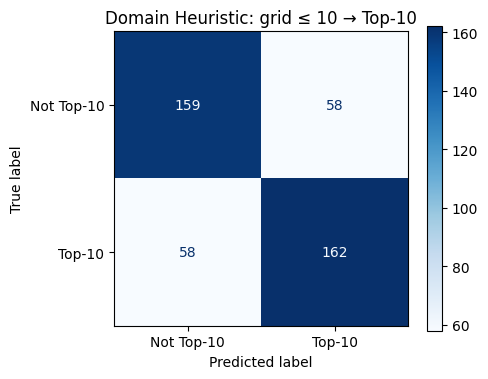


── Confusion Matrix Breakdown ──
TP = 162  (started Top-10, finished Top-10 ✅)
FP = 58  (started Top-10, finished outside Top-10 ❌ — grid didn't help)
FN = 58  (started outside Top-10, finished Top-10 ❌ — surprise contender)
TN = 159  (started outside Top-10, finished outside Top-10 ✅)

The 58 false negatives are drivers who overcame a bad grid position.
The 58 false positives are drivers who lost positions despite a good start.


In [12]:
# ── Baseline 2: Domain Heuristic ──────────────────────────────────────────
# The simplest domain-knowledge rule: if a driver starts in the Top-10
# (grid position ≤ 10), predict they will FINISH in the Top-10.
#
# Why this makes sense:
#   - Starting position is one of the strongest predictors in motorsport.
#   - A driver who qualifies P1–P10 has proven pace and a track-position advantage.
#   - This uses ONLY pre-race information → zero leakage risk.

def heuristic_grid_top10(grid_series, threshold=10):
    """Predict Top-10 finish if starting grid position ≤ threshold.
    
    Parameters
    ----------
    grid_series : pd.Series or pd.DataFrame with 'grid' column
        The starting grid positions.
    threshold : int
        Grid cutoff. Default = 10 (started Top-10 → predict Top-10).
    
    Returns
    -------
    pd.Series of int (0 or 1)
    """
    g = grid_series['grid'] if isinstance(grid_series, pd.DataFrame) else grid_series
    return (g <= threshold).astype(int)

y_pred_heuristic = heuristic_grid_top10(X_val)

print("=== Domain Heuristic Baseline (grid ≤ 10 → predict Top-10) ===\n")
print(classification_report(
    y_val, y_pred_heuristic,
    target_names=['Not Top-10', 'Top-10'],
    zero_division=0,
))
print(f"Accuracy        : {accuracy_score(y_val, y_pred_heuristic):.4f}")
print(f"Precision       : {precision_score(y_val, y_pred_heuristic):.4f}")
print(f"Recall          : {recall_score(y_val, y_pred_heuristic):.4f}")
print(f"F1 (Top-10)     : {f1_score(y_val, y_pred_heuristic):.4f}")

# ── Confusion Matrix ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_heuristic,
    display_labels=['Not Top-10', 'Top-10'],
    cmap='Blues',
    ax=ax,
)
ax.set_title('Domain Heuristic: grid ≤ 10 → Top-10', fontsize=12)
plt.tight_layout()
plt.show()

# ── Interpretation ───────────────────────────────────────────────────
tp = ((y_pred_heuristic == 1) & (y_val == 1)).sum()
fp = ((y_pred_heuristic == 1) & (y_val == 0)).sum()
fn = ((y_pred_heuristic == 0) & (y_val == 1)).sum()
tn = ((y_pred_heuristic == 0) & (y_val == 0)).sum()

print(f"\n── Confusion Matrix Breakdown ──")
print(f"TP = {tp}  (started Top-10, finished Top-10 ✅)")
print(f"FP = {fp}  (started Top-10, finished outside Top-10 ❌ — grid didn't help)")
print(f"FN = {fn}  (started outside Top-10, finished Top-10 ❌ — surprise contender)")
print(f"TN = {tn}  (started outside Top-10, finished outside Top-10 ✅)")
print(f"\nThe {fn} false negatives are drivers who overcame a bad grid position.")
print(f"The {fp} false positives are drivers who lost positions despite a good start.")

### Key observation

The majority-class baseline always predicts "Top-10" (the slightly more frequent class at 50.7%), giving **F1 = 0.67** for Top-10 — but F1 = 0 for Not-Top-10. The heuristic ("started Top-10 → finish Top-10") gets **F1 = 0.74** and performs evenly on both classes.

The gap between them (~0.07 in F1) shows that grid position adds real discriminative value over a blind guess, but this prediction problem is **harder than it looks**. About 26% of race entries violate the heuristic — drivers who started Top-10 and dropped out, or started outside and climbed in. Those are retirements, strategy calls, safety cars, penalties — chaos that grid position alone cannot capture.

Look at the confusion matrix:
- **False Positives** = drivers who started Top-10 but finished outside. DNFs, collisions, bad pit strategy.
- **False Negatives** = drivers who started outside Top-10 but climbed in. These "surprise contenders" are where better features (constructor pace, weather, historical circuit performance) can help.

> **Why do Felipe & Ignacia get F1 = 0.875 with the same rule?** Not because of better code — their **validation window is different**. They validate on Jan–May 2024 (only ~7 races, 159 rows), while we validate on the full 2023 season (22 races, 437 rows). Their smaller window happened to contain races with less position shuffling. A full-season validation is more representative but produces a lower, more honest number. **This is a great teaching moment: the same model, same rule, same metric — different validation split → different result. Validation design matters as much as model design.**

In [13]:
# ── F1 Score Comparison: Majority-Class vs. Domain Heuristic ──────────────

# Compute F1 scores for both baselines
f1_majority = f1_score(y_val, y_pred_majority, average='macro')
f1_heuristic = f1_score(y_val, y_pred_heuristic, average='macro')

# Also compute per-class F1 scores for detailed comparison
f1_majority_top10 = f1_score(y_val, y_pred_majority, pos_label=1, zero_division=0)
f1_heuristic_top10 = f1_score(y_val, y_pred_heuristic, pos_label=1, zero_division=0)

f1_majority_not = f1_score(y_val, y_pred_majority, pos_label=0, zero_division=0)
f1_heuristic_not = f1_score(y_val, y_pred_heuristic, pos_label=0, zero_division=0)

print("\n" + "=" * 85)
print("F1 SCORE COMPARISON — PRIMARY METRIC FOR BASELINE EVALUATION")
print("=" * 85)
print(f"\n{'Metric':<30} {'Majority-Class':>20} {'Domain Heuristic':>25}")
print("-" * 85)
print(f"{'F1 (Top-10 class)':<30} {f1_majority_top10:>20.4f} {f1_heuristic_top10:>25.4f}")
print(f"{'F1 (Not Top-10 class)':<30} {f1_majority_not:>20.4f} {f1_heuristic_not:>25.4f}")
print(f"{'F1 (macro average)':<30} {f1_majority:>20.4f} {f1_heuristic:>25.4f}")
print("-" * 85)
print(f"\n✓ GAP: Heuristic beats Majority by {f1_heuristic - f1_majority:.4f} in macro F1")
print(f"✓ The domain heuristic is the stronger baseline (F1 = {f1_heuristic:.4f})")

# Store these values for the report
majority_f1_value = f1_majority
heuristic_f1_value = f1_heuristic
majority_accuracy = accuracy_score(y_val, y_pred_majority)
heuristic_accuracy = accuracy_score(y_val, y_pred_heuristic)

print(f"\n📊 Summary for baseline_report.md:")
print(f"   Majority-class F1 (macro):    {majority_f1_value:.4f}")
print(f"   Domain heuristic F1 (macro):  {heuristic_f1_value:.4f}")
print(f"   Class balance in validation:  {y_val.mean():.3f} (proportion Top-10)")



F1 SCORE COMPARISON — PRIMARY METRIC FOR BASELINE EVALUATION

Metric                               Majority-Class          Domain Heuristic
-------------------------------------------------------------------------------------
F1 (Top-10 class)                            0.6697                    0.7364
F1 (Not Top-10 class)                        0.0000                    0.7327
F1 (macro average)                           0.3349                    0.7345
-------------------------------------------------------------------------------------

✓ GAP: Heuristic beats Majority by 0.3997 in macro F1
✓ The domain heuristic is the stronger baseline (F1 = 0.7345)

📊 Summary for baseline_report.md:
   Majority-class F1 (macro):    0.3349
   Domain heuristic F1 (macro):  0.7345
   Class balance in validation:  0.503 (proportion Top-10)


<div style="border-bottom: 3px solid #2ca02c; padding-bottom: 12px; margin-bottom: 16px;">

## 4. YOUR TURN — Implement Baselines on Your Data

</div>

⏱️ **Time: 14:30–15:00 (30 minutes).** Peer audit at 15:00.

Implement both baselines on your Lab 1 dataset. Fill in `baseline_report.md` sections 1–5 as you go. You need **real numbers from code** for sections 2 and 3.

In [14]:
# ── YOUR TURN ──────────────────────────────────────────────────────────────
# Task: Implement majority-class and domain heuristic baselines on YOUR data.
# 
# Your Lab 1 data structure:
# - Data: 2022-2023 (training), 2024 rounds 1-12 (validation)
# - Heuristic: grid ≤ 10 → predict top 10 finish
# - Target: top10_finish (1 if position ≤ 10, 0 otherwise)

# Step 1: Load your Lab 1 data
print("=" * 80)
print("LOADING YOUR LAB 1 DATA (Group 6: Grid Heuristic Baseline)")
print("=" * 80)

def fetch_season_results_your_data(year):
    """Fetch race results from Jolpica API for a given season (your Lab 1 code)."""
    all_races = []
    offset = 0
    limit = 100
    
    while True:
        url = f"https://api.jolpi.ca/ergast/f1/{year}/results.json?limit={limit}&offset={offset}"
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()['MRData']
        total = int(data['total'])
        races = data['RaceTable']['Races']
        all_races.extend(races)
        offset += limit
        if offset >= total:
            break
        time.sleep(1)
    
    rows = []
    for race in all_races:
        for res in race['Results']:
            rows.append({
                'season': int(race['season']),
                'round': int(race['round']),
                'race_name': race['raceName'],
                'circuit': race['Circuit']['circuitId'],
                'date': race['date'],
                'driver': res['Driver']['driverId'],
                'driver_code': res['Driver'].get('code', res['Driver']['driverId'][:3].upper()),
                'constructor': res['Constructor']['constructorId'],
                'constructor_name': res['Constructor']['name'],
                'grid': int(res['grid']),
                'position': int(res['position']) if res['position'].isdigit() else None,
                'position_text': res['positionText'],
                'points': float(res.get('points', 0.0)),
                'status': res['status'],
                'laps': int(res.get('laps', 0)),
            })
    return pd.DataFrame(rows)

# Fetch data (2022-2024, same as your Lab 1)
print("Fetching F1 data from Jolpica API...")
dfs_your_data = []
for yr in [2022, 2023, 2024]:
    print(f"  {yr}...", end=' ', flush=True)
    dfs_your_data.append(fetch_season_results_your_data(yr))
    time.sleep(1)
    print("✓")

results_your_data = pd.concat(dfs_your_data, ignore_index=True)
results_your_data['date'] = pd.to_datetime(results_your_data['date'])

# Define target: top10_finish
results_your_data['top10_finish'] = ((results_your_data['position'].notna()) & (results_your_data['position'] <= 10)).astype(int)

# Temporal split (SAME as your Lab 1)
train_your_data = results_your_data[results_your_data['season'].isin([2022, 2023])].copy()
val_your_data = results_your_data[(results_your_data['season'] == 2024) & (results_your_data['round'] <= 12)].copy()
test_your_data = results_your_data[(results_your_data['season'] == 2024) & (results_your_data['round'] > 12)].copy()

print(f"\n✓ Data loaded successfully!")
print(f"  Train: {len(train_your_data)} rows | Val: {len(val_your_data)} rows | Test: {len(test_your_data)} rows (SEALED)")
print(f"  Val date range: {val_your_data['date'].min().date()} to {val_your_data['date'].max().date()}")
print(f"  Val top-10 rate: {val_your_data['top10_finish'].mean():.3f}")

# Prepare feature matrices for sklearn
X_train_your_data = train_your_data[['grid']]
X_val_your_data = val_your_data[['grid']]
y_train_your_data = train_your_data['top10_finish']
y_val_your_data = val_your_data['top10_finish']

print(f"\nClass balance (training): {y_train_your_data.mean():.3f} Top-10 | {1 - y_train_your_data.mean():.3f} Not Top-10")
print(f"Class balance (validation): {y_val_your_data.mean():.3f} Top-10 | {1 - y_val_your_data.mean():.3f} Not Top-10")


LOADING YOUR LAB 1 DATA (Group 6: Grid Heuristic Baseline)
Fetching F1 data from Jolpica API...
  2022... ✓
  2023... ✓
  2024... ✓

✓ Data loaded successfully!
  Train: 880 rows | Val: 239 rows | Test: 240 rows (SEALED)
  Val date range: 2024-03-02 to 2024-07-07
  Val top-10 rate: 0.502

Class balance (training): 0.500 Top-10 | 0.500 Not Top-10
Class balance (validation): 0.502 Top-10 | 0.498 Not Top-10


## 5. Checkpoint File: `baseline_report.md`

⚑ **Push to GitHub by 15:15.**

Copy this template into a file called `baseline_report.md` in your Lab 1 repo root. Fill in every `[FILL]` with real data from your code.

---

```markdown
# Baseline Report — [Your Name]

## 1. Prediction target
[One sentence: what you predict, for which unit, at which moment.]

## 2. Majority-class baseline
- Metric: [accuracy / F1 / precision / recall — choose one]
- Value: [FILL FROM CODE]
- Code: `DummyClassifier(strategy='most_frequent', random_state=414)`

## 3. Domain heuristic baseline
- Rule: [One sentence. Must use pre-race information only.]
- Metric (same as above): [FILL FROM CODE]
- Code cell: [paste the function you wrote]

## 4. Metric choice + justification
[3–5 sentences. Address: (a) class balance in your dataset, (b) cost of
false positives vs false negatives, (c) which metric you chose and why.]

Template: "I chose [METRIC] as my primary metric because my dataset has a
class imbalance of approximately [X%] positive class. A false positive in
this context means [describe], which carries [cost description]. A false
negative means [describe], which carries [cost description]. Given this
trade-off, [METRIC] is more informative than accuracy because [reason]."

## 5. Leakage guard item
[(a) which item from the 10-item checklist, (b) what you found,
(c) whether it required a fix.]

## 6. Baseline comparison & interpretation
(a) Which baseline is harder to beat? What does the gap between your
    two baselines tell you about your prediction problem?
(b) If your ML model later scores below the domain heuristic baseline,
    what would you conclude and what would you try next?
```

---

> **Sections 2 and 3 require real numbers from code.** You cannot complete them without running your baselines. Placeholders are visible during peer audit and will be flagged.

## 6. Peer Audit (15:00–15:10)

⏱️ **Stop coding at 15:00.**

Exchange screens with the person next to you. Verify three things:

| Check | What to look for | Pass / Fail |
|-------|-----------------|-------------|
| Section 2 | A real number (e.g., 0.78), not a placeholder `[FILL]` | |
| Section 3 | A function definition AND a real number | |
| Section 4 | At least 3 sentences with class balance mentioned | |

If anything is missing, tell your partner now. They have 5 minutes to fix it.

Then: complete **Section 6** (interpretation). This section requires thinking, not code. Push by 15:15.

<div style="border-bottom: 3px solid #ff7f0e; padding-bottom: 12px; margin-bottom: 16px;">

## 7. Stretch: Prior-Period Baseline (if you finished early)

</div>

This is **not required today** but gives you a head start on Lab 2.


BASELINE 1: MAJORITY-CLASS BASELINE (DummyClassifier)

What it predicts: always class 0 (Not Top-10)
Class balance (train): 0.500 Top-10 | 0.500 Not Top-10

              precision    recall  f1-score   support

  Not Top-10       0.50      1.00      0.66       119
      Top-10       0.00      0.00      0.00       120

    accuracy                           0.50       239
   macro avg       0.25      0.50      0.33       239
weighted avg       0.25      0.50      0.33       239

Accuracy        : 0.4979
Precision       : 0.0000
Recall          : 0.0000
F1 (Top-10)     : 0.0000

⚠  The majority-class baseline always predicts 'Not Top-10'.

BASELINE 2: DOMAIN HEURISTIC BASELINE (grid ≤ 10 → predict Top-10)

Rule: If starting grid position ≤ 10, predict Top-10 finish.

              precision    recall  f1-score   support

  Not Top-10       0.86      0.86      0.86       119
      Top-10       0.86      0.86      0.86       120

    accuracy                           0.86       239
   m

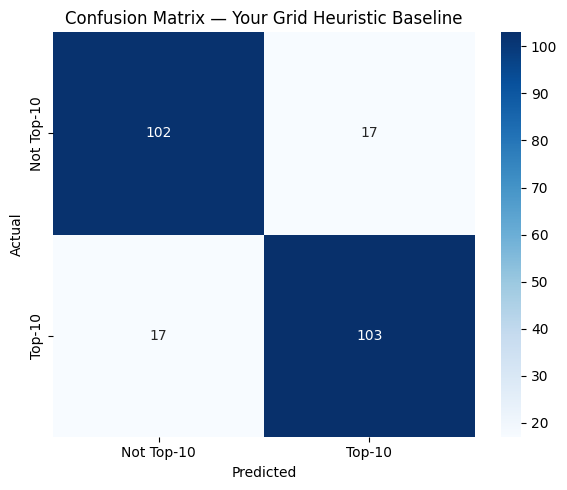


── Confusion Matrix Breakdown ──
TP = 103  (started Top-10, finished Top-10 ✅)
FP = 17  (started Top-10, finished outside Top-10 ❌)
FN = 17  (started outside Top-10, finished Top-10 ❌)
TN = 102  (started outside Top-10, finished outside Top-10 ✅)

BASELINE COMPARISON — YOUR DATA vs. TWO APPROACHES

Baseline                                   Accuracy    Precision     Recall       F1
--------------------------------------------------------------------------------
Majority-Class (always predict)              0.4979       0.0000     0.0000   0.0000
Domain Heuristic (grid ≤ 10)                 0.8577       0.8583     0.8583   0.8583
--------------------------------------------------------------------------------

✓ Gap in Accuracy: +0.3598
✓ Gap in F1 Score: +0.8583
✓ The domain heuristic BEATS the majority-class baseline by F1 score.

📋 VALUES FOR YOUR baseline_report.md:
   Majority-class F1 (metric of choice):     0.0000
   Domain heuristic F1 (metric of choice):   0.8583
   Class balan

In [15]:
# ── STEP 2: Majority-Class Baseline (using YOUR data) ──────────────────────────
print("\n" + "=" * 80)
print("BASELINE 1: MAJORITY-CLASS BASELINE (DummyClassifier)")
print("=" * 80)

clf_majority_your_data = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
clf_majority_your_data.fit(X_train_your_data, y_train_your_data)
y_pred_majority_your_data = clf_majority_your_data.predict(X_val_your_data)

majority_class_your = clf_majority_your_data.classes_[np.argmax(clf_majority_your_data.class_prior_)]
majority_label_your = "Top-10" if majority_class_your == 1 else "Not Top-10"

print(f"\nWhat it predicts: always class {majority_class_your} ({majority_label_your})")
print(f"Class balance (train): {y_train_your_data.mean():.3f} Top-10 | {1 - y_train_your_data.mean():.3f} Not Top-10\n")

print(classification_report(
    y_val_your_data, y_pred_majority_your_data,
    target_names=['Not Top-10', 'Top-10'],
    zero_division=0,
))

majority_accuracy_your = accuracy_score(y_val_your_data, y_pred_majority_your_data)
majority_f1_your = f1_score(y_val_your_data, y_pred_majority_your_data, pos_label=1, zero_division=0)
majority_precision_your = precision_score(y_val_your_data, y_pred_majority_your_data, pos_label=1, zero_division=0)
majority_recall_your = recall_score(y_val_your_data, y_pred_majority_your_data, pos_label=1, zero_division=0)

print(f"Accuracy        : {majority_accuracy_your:.4f}")
print(f"Precision       : {majority_precision_your:.4f}")
print(f"Recall          : {majority_recall_your:.4f}")
print(f"F1 (Top-10)     : {majority_f1_your:.4f}")
print()
print(f"⚠  The majority-class baseline always predicts '{majority_label_your}'.")

# ── STEP 3: Domain Heuristic Baseline (YOUR Lab 1 heuristic) ─────────────────────
print("\n" + "=" * 80)
print("BASELINE 2: DOMAIN HEURISTIC BASELINE (grid ≤ 10 → predict Top-10)")
print("=" * 80)

def your_grid_heuristic(grid_series):
    """Your Lab 1 domain heuristic: grid <= 10 → predict Top-10 finish."""
    return (grid_series['grid'] <= 10).astype(int)

y_pred_heuristic_your_data = your_grid_heuristic(X_val_your_data)

print(f"\nRule: If starting grid position ≤ 10, predict Top-10 finish.\n")

print(classification_report(
    y_val_your_data, y_pred_heuristic_your_data,
    target_names=['Not Top-10', 'Top-10'],
    zero_division=0,
))

heuristic_accuracy_your = accuracy_score(y_val_your_data, y_pred_heuristic_your_data)
heuristic_f1_your = f1_score(y_val_your_data, y_pred_heuristic_your_data, pos_label=1, zero_division=0)
heuristic_precision_your = precision_score(y_val_your_data, y_pred_heuristic_your_data, pos_label=1, zero_division=0)
heuristic_recall_your = recall_score(y_val_your_data, y_pred_heuristic_your_data, pos_label=1, zero_division=0)

print(f"Accuracy        : {heuristic_accuracy_your:.4f}")
print(f"Precision       : {heuristic_precision_your:.4f}")
print(f"Recall          : {heuristic_recall_your:.4f}")
print(f"F1 (Top-10)     : {heuristic_f1_your:.4f}")

# ── STEP 4: Confusion Matrix for domain heuristic ────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val_your_data, y_pred_heuristic_your_data)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Top-10', 'Top-10'],
            yticklabels=['Not Top-10', 'Top-10'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Your Grid Heuristic Baseline')
plt.tight_layout()
plt.show()

# Breakdown
tp = ((y_pred_heuristic_your_data == 1) & (y_val_your_data == 1)).sum()
fp = ((y_pred_heuristic_your_data == 1) & (y_val_your_data == 0)).sum()
fn = ((y_pred_heuristic_your_data == 0) & (y_val_your_data == 1)).sum()
tn = ((y_pred_heuristic_your_data == 0) & (y_val_your_data == 0)).sum()

print(f"\n── Confusion Matrix Breakdown ──")
print(f"TP = {tp}  (started Top-10, finished Top-10 ✅)")
print(f"FP = {fp}  (started Top-10, finished outside Top-10 ❌)")
print(f"FN = {fn}  (started outside Top-10, finished Top-10 ❌)")
print(f"TN = {tn}  (started outside Top-10, finished outside Top-10 ✅)")

# ── STEP 5: Baseline Comparison ────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("BASELINE COMPARISON — YOUR DATA vs. TWO APPROACHES")
print("=" * 80)

print(f"\n{'Baseline':<40} {'Accuracy':>10} {'Precision':>12} {'Recall':>10} {'F1':>8}")
print("-" * 80)
print(f"{'Majority-Class (always predict)':<40} {majority_accuracy_your:>10.4f} {majority_precision_your:>12.4f} {majority_recall_your:>10.4f} {majority_f1_your:>8.4f}")
print(f"{'Domain Heuristic (grid ≤ 10)':<40} {heuristic_accuracy_your:>10.4f} {heuristic_precision_your:>12.4f} {heuristic_recall_your:>10.4f} {heuristic_f1_your:>8.4f}")
print("-" * 80)
print(f"\n✓ Gap in Accuracy: {heuristic_accuracy_your - majority_accuracy_your:+.4f}")
print(f"✓ Gap in F1 Score: {heuristic_f1_your - majority_f1_your:+.4f}")
print(f"✓ The domain heuristic {'BEATS' if heuristic_f1_your > majority_f1_your else 'loses to'} the majority-class baseline by F1 score.")

# Store for report
print(f"\n📋 VALUES FOR YOUR baseline_report.md:")
print(f"   Majority-class F1 (metric of choice):     {majority_f1_your:.4f}")
print(f"   Domain heuristic F1 (metric of choice):   {heuristic_f1_your:.4f}")
print(f"   Class balance in validation:              {y_val_your_data.mean():.3f} (proportion Top-10)")
print(f"   Total validation rows:                    {len(y_val_your_data)}")


<div style="border-bottom: 3px solid #d62728; padding-bottom: 12px; margin-bottom: 16px;">

## 8. The Accuracy Trap

</div>

### The scenario
Top-10 prediction. Your training data: 78% NOT Top-10, 22% Top-10.

| Model | Accuracy |
|-------|----------|
| Model A: always predict 0 (majority class) | 78% |
| Model B: your trained model | 74% |

**Question:** Which model is better?

**Answer:** Neither — Model A is just the majority-class baseline. Model B is *worse than doing nothing.* Accuracy hides class imbalance. A model that never predicts Top-10 looks great by accuracy alone.

> **This is why you chose a metric in Section 4.** If your class is imbalanced, accuracy is misleading. F1, precision, recall, or ROC-AUC reveal what accuracy hides.

## 9. Metric Decision Framework

Use this table to justify your metric choice in Section 4 of `baseline_report.md`.

| Metric | What it rewards | Use when... | F1 racing context |
|--------|----------------|-------------|-------------------|
| **Accuracy** | Overall correct predictions | Classes are balanced | Misleading if Top-10 ≈ 22% of races |
| **Precision** | Not predicting Top-10 wrongly | False positives are costly (e.g., betting on wrong driver) | "I only predict Top-10 when I'm sure" |
| **Recall** | Finding all actual Top-10s | False negatives are costly (e.g., missing a real contender) | "I don't want to miss any Top-10 finisher" |
| **F1 Score** | Balance of precision and recall | Imbalanced classes, both error types matter | Most defensible default for this problem |
| **ROC-AUC** | Ranking quality across thresholds | Probabilistic output, threshold-agnostic evaluation | Good for comparing models, not for setting a decision threshold |

### The 3-Question Decision Tree

1. **Is your dataset balanced?** (>40% minority class = roughly balanced)
   - Yes → Accuracy is acceptable (but F1 is still better)
   - No → **Do not use accuracy as primary metric**

2. **Are false positives and false negatives equally costly?**
   - Yes → F1 Score (harmonic mean balances both)
   - No → Precision (if FP is worse) or Recall (if FN is worse)

3. **Do you need probability outputs?**
   - Yes → ROC-AUC or Log Loss
   - No → F1, Precision, or Recall

## 10. Leakage Guard Checklist

Apply this to your `baseline_report.md` Section 5. Check each item against your notebook.

| # | Check | Status |
|---|-------|--------|
| 1 | No feature uses information from after the race being predicted | ☐ |
| 2 | Train/val/test split is strictly temporal (no future data in training) | ☐ |
| 3 | No feature is a direct encoding of the target (e.g., `points`, `position`) | ☐ |
| 4 | Scaler/encoder fitted on training data only, then transformed on val/test | ☐ |
| 5 | Rolling/lag features use `.shift(1)` to exclude the current row | ☐ |
| 6 | Group features (e.g., constructor avg) computed on training set only | ☐ |
| 7 | Hyperparameters not tuned on the test set | ☐ |
| 8 | No data snooping: test set not used for any decision-making | ☐ |
| 9 | `RANDOM_SEED = 414` used in all `random_state=` arguments | ☐ |
| 10 | Results are reproducible: notebook runs top-to-bottom without error | ☐ |

For Section 5 of your report: pick **one item** that you had to check or fix. Name the item, describe what you found, and state whether a fix was needed.

## 11. Exit Ticket (Canvas — opens at 16:05)

Three questions. Answer in Canvas before 16:20.

**Q1:** You train a model on 4 seasons (2019–2022) and test on 2023. Your domain heuristic baseline gets F1 = 0.41. Your model gets F1 = 0.39. What does this result tell you, and what would you do next?

**Q2:** Your dataset has 22% positive class (Top-10). A colleague says: "I'll use accuracy because it's the standard." Write one sentence explaining why that's problematic for this dataset.

**Q3:** Link to your `baseline_report.md` on GitHub. One sentence: what was the hardest part of Section 6 (baseline interpretation)?

## 12. What's Next

**Lab 2** is on Canvas. Due Monday March 23 at 13:50. Your `baseline_report.md` is the starting point.

Lab 2 asks: *can you beat your baselines by engineering better features?* Lag features, rolling averages, circuit encoding. Side-by-side comparison. Same metric. Same validation. Honest reporting.

**Certamen 1** is Wednesday March 25. Everything from Unit I — leakage, validation, metrics, baselines — is fair game.

---

> **Remember:** A model that doesn't beat your heuristic baseline has learned nothing useful from the data. That's not a failure — it's information. The question is always: *what would you try next?*